In [166]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from utils import load_results

# Plot style
sns.set_theme(style="ticks")

In [167]:
editing_csv_path = "../results/editing/editing_summary_detailed.csv"

# Execute the loader and show a quick summary/preview
df_bilinear = load_results("../results/rescal", "rescal_accuracy*.json")
df_composition = load_results("../results/rescal", "rescal_composition*.json")
df_transpose = load_results("../results/rescal", "rescal_transpose*.json")

train_df = pd.read_json("../results/training/aggregated_results.json")
train_df = train_df.rename(columns={"weight_decay": "Weight Decay", "seed": "Seed", "layer": "Layer"})
df = pd.read_csv(editing_csv_path)
# Ensure numeric dtypes
df['Layer'] = pd.to_numeric(df['Layer'], errors='coerce').astype(int)
df = df[df["Direction"]=="BI"]

In [168]:
# Define thresholds for grouping
threshold_low = 0.4
threshold_high = 0.98

# Create masks for the two groups based on train_df
mask_g1 = (train_df['reverse_uni_acc'] < threshold_low)# & (train_df['Weight Decay'] > 0.1)
mask_g2 = train_df['reverse_uni_acc'] > threshold_high

# Get the runs for each group
g1_runs = train_df[mask_g1][['Weight Decay', 'Seed']]
g2_runs = train_df[mask_g2][['Weight Decay', 'Seed']]

# Filter df based on Subfolder matching the runs
# Create tuples for matching
g1_tuples = set(zip(g1_runs['Weight Decay'], g1_runs['Seed']))
g2_tuples = set(zip(g2_runs['Weight Decay'], g2_runs['Seed']))

print(len(g1_tuples))
print(len(g2_tuples))
# Filter df for each group
df_g1 = df[df[['Weight Decay', 'Seed']].apply(tuple, axis=1).isin(g1_tuples)].copy()
df_g2 = df[df[['Weight Decay', 'Seed']].apply(tuple, axis=1).isin(g2_tuples)].copy()

# Add group labels
df_g1['group'] = 'Reversal Cursed'
df_g2['group'] = 'Not Reversal Cursed'

# Combine into one dataframe if needed
df = pd.concat([df_g1, df_g2], ignore_index=True)

14
8


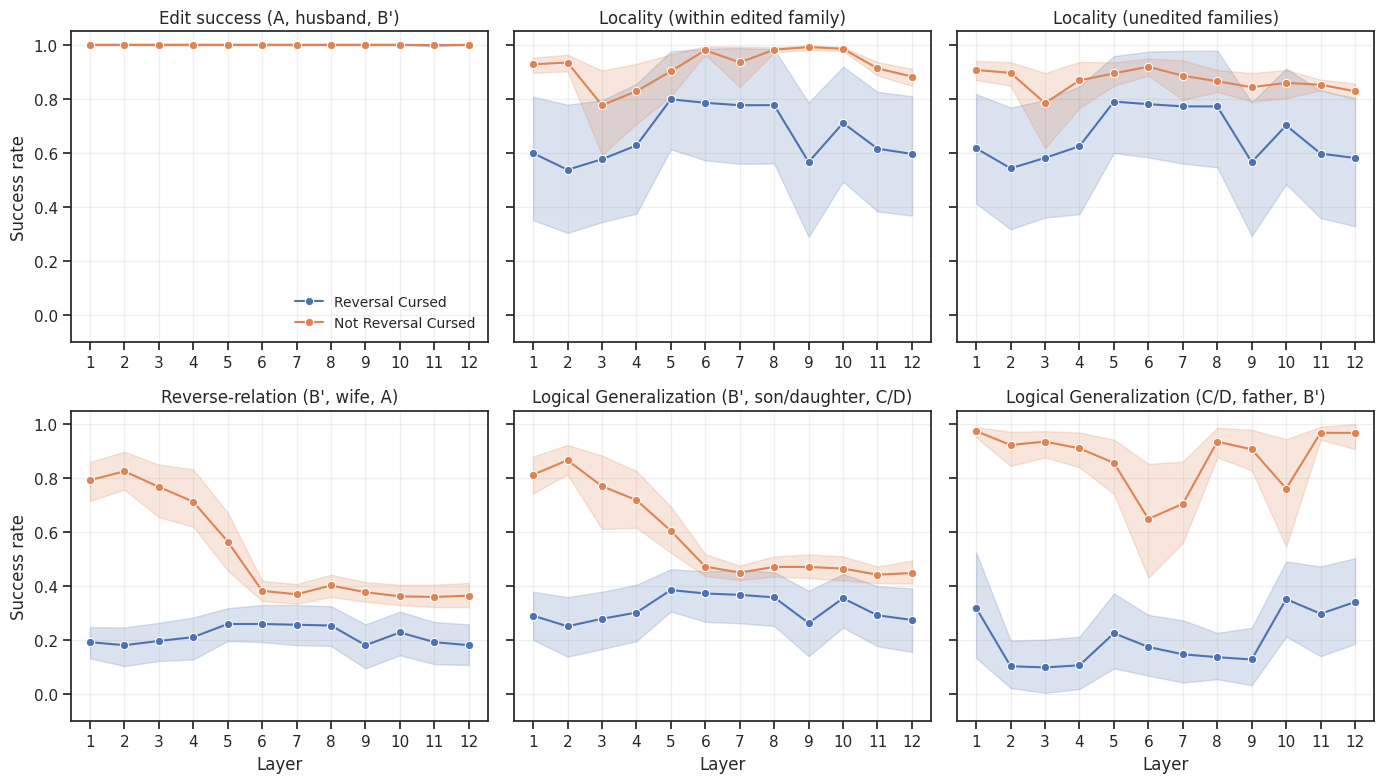

In [169]:
# Rename metrics for plotting
metrics_map = {
    'Edit Success Rate': "Edit success (A, husband, B')",
    'Reversal Success Rate': "Reverse-relation (B', wife, A)",
    'Nbr New2Org Success Rate': "Logical Generalization (B', son/daughter, C/D)",
    'Nbr Org2New Success Rate': "Logical Generalization (C/D, father, B')",
    'Unrelated Success Rate': "Locality (within edited family)"
}

# Compute average metrics and visualize (same style as above)
lg_cols = [
    "Reverse-relation (B', wife, A)",
    "Logical Generalization (B', son/daughter, C/D)",
    "Logical Generalization (C/D, father, B')",
]
loc_cols = [
    "Locality (within edited family)",
    "Locality (unedited families)",
]

# Compute average Holdout success rate as 'Locality (unedited families)'
holdout_cols = [col for col in df.columns if col.startswith('Holdout') and 'Success Rate' in col]
df["Locality (unedited families)"] = df[holdout_cols].mean(axis=1) if holdout_cols else None

# Prepare df for plotting (rename columns)
df_plot = df.rename(columns=metrics_map)

# 2x3 grid:
# - Top row: Edit success + two locality metrics
# - Bottom row: three logical generalization metrics
top_metrics = ["Edit success (A, husband, B')"] + loc_cols
bottom_metrics = lg_cols

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)

# Helper to plot one metric on a given axis following the custom format
def plot_metric(ax, metric, show_legend=False):
    sns.lineplot(
        data=df_plot,
        x="Layer",
        y=metric,
        ax=ax,
        marker="o",
        hue="group",
    )
    ax.set_ylim(-0.1, 1.05)
    layers = sorted(df_plot['Layer'].unique())
    ax.set_xticks(layers)
    ax.set_xticklabels([x + 1 for x in layers])
    ax.set_ylabel("Success rate")
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
    if show_legend:
        ax.legend(fontsize=10, loc="lower right", frameon=False)
    else:
        if ax.get_legend():
            ax.legend_.remove()

# Top row
for j, metric in enumerate(top_metrics):
    plot_metric(axes[0, j], metric, show_legend=j == 0)
    axes[0, j].set_xlabel("")

# Bottom row
for j, metric in enumerate(bottom_metrics):
    plot_metric(axes[1, j], metric, show_legend=False)

plt.tight_layout()
# plt.show()
plt.savefig("SM-Editing_details.pdf", bbox_inches='tight')

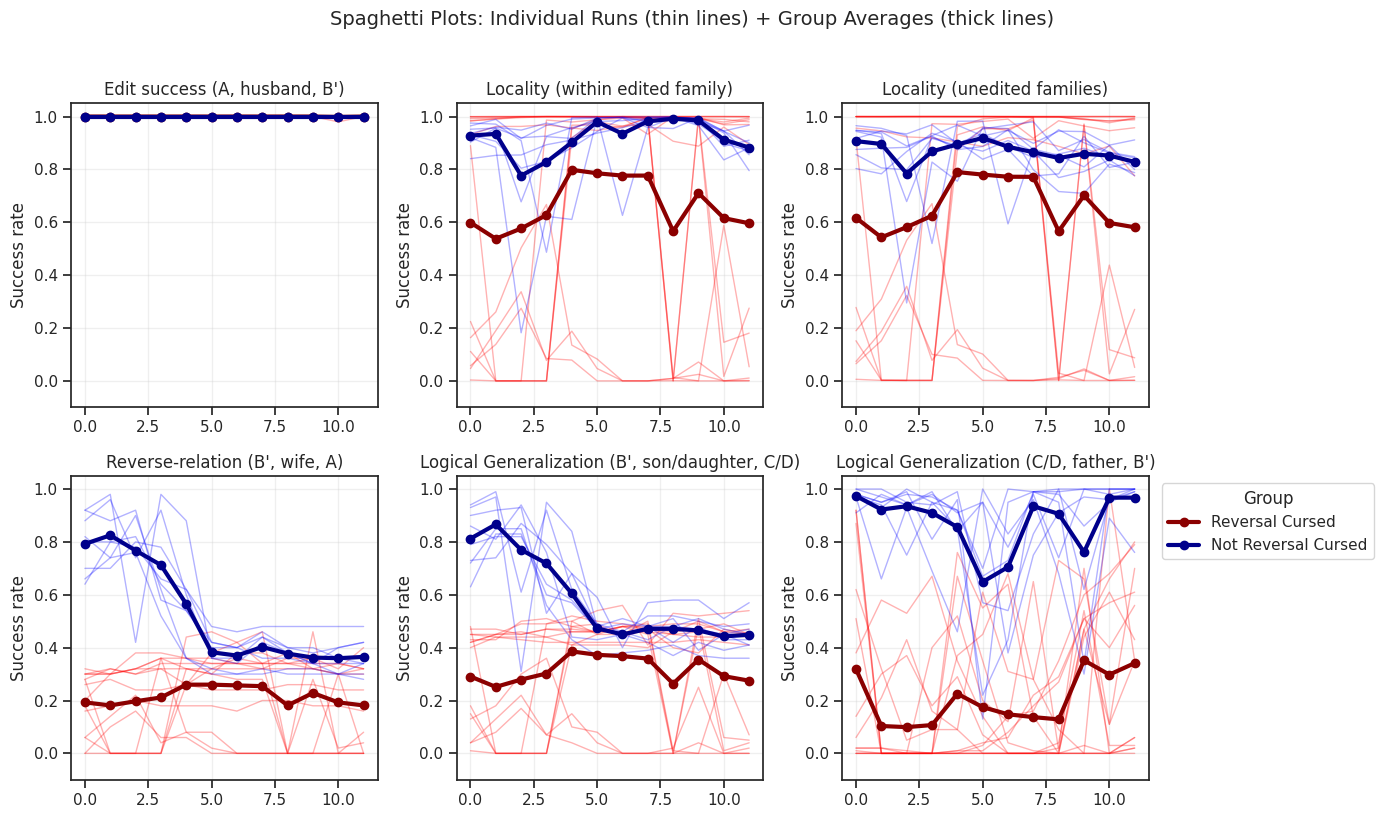

In [170]:
# Create spaghetti plots for each metric by group
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Helper function to create spaghetti plot
def plot_spaghetti(ax, metric, show_legend=False):
    # Plot individual runs as thin lines
    for group_name in ['Reversal Cursed', 'Not Reversal Cursed']:
        group_data = df_plot[df_plot['group'] == group_name]
        
        # Group by Weight Decay and Seed to get individual runs
        for (wd, seed), run_data in group_data.groupby(['Weight Decay', 'Seed']):
            run_data = run_data.sort_values('Layer')
            ax.plot(run_data['Layer'], run_data[metric], 
                   alpha=0.3, linewidth=1, 
                   color='red' if group_name == 'Reversal Cursed' else 'blue')
    
    # Plot group averages as thick lines
    for group_name in ['Reversal Cursed', 'Not Reversal Cursed']:
        group_avg = df_plot[df_plot['group'] == group_name].groupby('Layer')[metric].mean()
        ax.plot(group_avg.index, group_avg.values, 
               linewidth=3, marker='o', markersize=6,
               color='darkred' if group_name == 'Reversal Cursed' else 'darkblue',
               label=group_name)
    
    ax.set_ylim(-0.1, 1.05)
    ax.set_ylabel("Success rate")
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
    
    if show_legend:
        ax.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        if ax.get_legend():
            ax.legend_.remove()

# Top row
for j, metric in enumerate(top_metrics):
    plot_spaghetti(axes[0, j], metric, show_legend=False)

# Bottom row  
for j, metric in enumerate(bottom_metrics):
    show_legend = (j == len(bottom_metrics) - 1)
    plot_spaghetti(axes[1, j], metric, show_legend=show_legend)

plt.suptitle("Spaghetti Plots: Individual Runs (thin lines) + Group Averages (thick lines)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [171]:
df_plot.keys()

Index(['Method', 'Base_Method', 'Layer', 'Weight Decay', 'Seed', 'Subfolder',
       'Model', 'Direction', 'Edit success (A, husband, B')',
       'Reverse-relation (B', wife, A)',
       'Logical Generalization (B', son/daughter, C/D)',
       'Logical Generalization (C/D, father, B')',
       'Locality (within edited family)', 'Pre Edit Success Rate',
       'Pre Reversal Success Rate', 'Pre Nbr New2Org Success Rate',
       'Pre Nbr Org2New Success Rate', 'Pre Unrelated Success Rate',
       'Avg Time (s)', 'Num Cases', 'Holdout Edit Success Rate',
       'Holdout Reversal Success Rate', 'Holdout Nbr New2Org Success Rate',
       'Holdout Nbr Org2New Success Rate', 'Holdout Unrelated Success Rate',
       'group', 'Locality (unedited families)'],
      dtype='object')

In [172]:
df_plot["group"].unique()

array(['Reversal Cursed', 'Not Reversal Cursed'], dtype=object)

{'Logical Generalization (avg)': np.float64(0.39609848484848487), 'Locality (avg)': np.float64(0.74628651010101)}


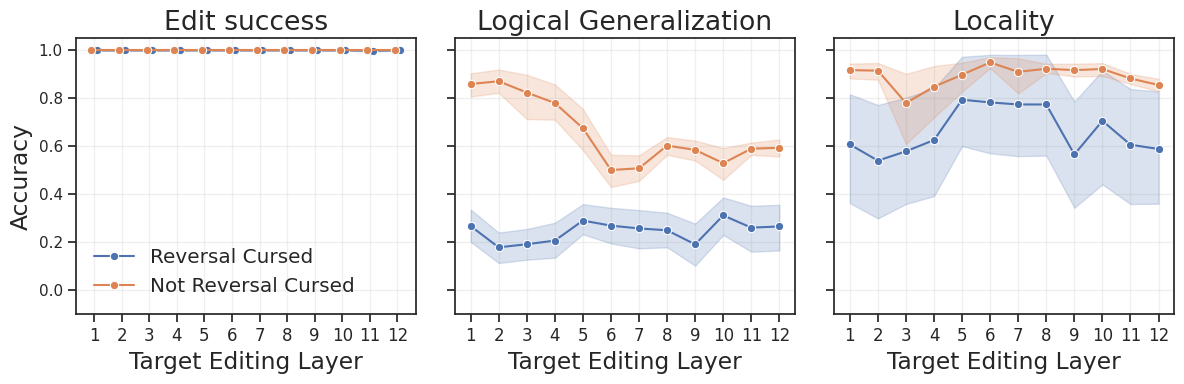

In [173]:
# Compute average metrics and visualize (same style as above)
lg_cols = [
    "Reverse-relation (B', wife, A)",
    "Logical Generalization (B', son/daughter, C/D)",
    "Logical Generalization (C/D, father, B')",
]
loc_cols = [
    "Locality (within edited family)",
    "Locality (unedited families)",
]

# Add averaged columns
df_plot["Logical Generalization (avg)"] = df_plot[lg_cols].mean(axis=1)
df_plot["Locality (avg)"] = df_plot[loc_cols].mean(axis=1)
 
# Quick summary of overall averages
print({
    "Logical Generalization (avg)": df_plot["Logical Generalization (avg)"].mean(),
    "Locality (avg)": df_plot["Locality (avg)"].mean(),
})

# Visualize group-wise averages over layers for the new averaged metrics
avg_metrics = ["Edit success (A, husband, B')", "Logical Generalization (avg)", "Locality (avg)"]


titles = ["Edit success", "Logical Generalization", "Locality"]
df_plot['Layer'] = df_plot.apply(lambda r: r['Layer'] + 1, axis=1)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
font_scale=1.2
for i, m in enumerate(avg_metrics):
    if i ==0:
        # add a tiny x-offset (+0.05 per group) so the lines don’t perfectly overlap
        offsets = {
            'Reversal Cursed': 0.1,
            'Not Reversal Cursed': -0.1,
        }
        df_plot2 = df_plot.copy()
        df_plot2['Layer'] = df_plot.apply(lambda r: r['Layer'] + offsets[r['group']], axis=1)
        sns.lineplot(
            data=df_plot2,
            x="Layer",
            y=m,
            hue="group",
            marker="o",
            ax=axes[i],
        )

    else:
        sns.lineplot(
            data=df_plot,
            x="Layer",
            y=m,
            hue="group",
            marker="o",
            ax=axes[i],
        )
    # layers = sorted(df_plot['Layer'].unique())
    axes[i].set_xticks([i + 1 for i in range(12)])
    axes[i].set_xticklabels([i + 1 for i in range(12)], fontsize=10*font_scale)
    # axes[i].set_yticklabels(fontsize=10*font_scale)

    axes[i].set_ylim(-0.1, 1.05)
    axes[i].set_ylabel("Accuracy", fontsize=14*font_scale)
    axes[i].set_xlabel("Target Editing Layer", fontsize=14*font_scale)
    axes[i].set_title(titles[i], fontsize=16*font_scale)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(title="", loc="lower left", frameon=False, fontsize=12*font_scale)
    else:
        if axes[i].get_legend():
            axes[i].legend_.remove()
plt.tight_layout()
plt.savefig("editing_result.pdf", bbox_inches='tight')

In [174]:
df = pd.read_csv(editing_csv_path)
# Ensure numeric dtypes
df['Layer'] = pd.to_numeric(df['Layer'], errors='coerce').astype(int)
df = df[df["Direction"]=="BI"]

# Rename metrics for plotting
metrics_map = {
    'Edit Success Rate': "Edit success (A, husband, B')",
    'Reversal Success Rate': "Reverse-relation (B', wife, A)",
    'Nbr New2Org Success Rate': "Logical Generalization (B', son/daughter, C/D)",
    'Nbr Org2New Success Rate': "Logical Generalization (C/D, father, B')",
    'Unrelated Success Rate': "Locality (within edited family)"
}

# Compute average metrics and visualize (same style as above)
lg_cols = [
    "Reverse-relation (B', wife, A)",
    "Logical Generalization (B', son/daughter, C/D)",
    "Logical Generalization (C/D, father, B')",
]
loc_cols = [
    "Locality (within edited family)",
    "Locality (unedited families)",
]

# Compute average metrics and visualize (same style as above)
lg_cols = [
    "Reverse-relation (B', wife, A)",
    "Logical Generalization (B', son/daughter, C/D)",
    "Logical Generalization (C/D, father, B')",
]
loc_cols = [
    "Locality (within edited family)",
    "Locality (unedited families)",
]

# Compute average Holdout success rate as 'Locality (unedited families)'
holdout_cols = [col for col in df.columns if col.startswith('Holdout') and 'Success Rate' in col]
df["Locality (unedited families)"] = df[holdout_cols].mean(axis=1) if holdout_cols else None

df_plot2 = df.rename(columns=metrics_map)

# Add averaged columns
df_plot2["Logical Generalization (avg)"] = df_plot2[lg_cols].mean(axis=1)
df_plot2["Locality (avg)"] = df_plot2[loc_cols].mean(axis=1)

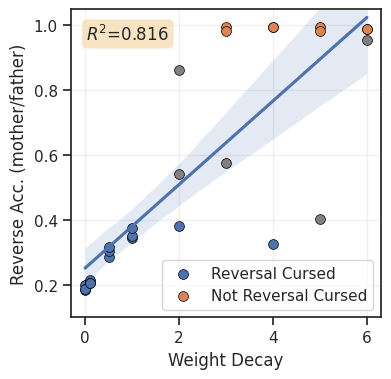

In [175]:
# Get best bilinear accuracy and the corresponding layer for each (wd, seed) pair
idx = df_bilinear[df_bilinear.relation == "overall"].groupby(['wd', 'seed'])['accuracy'].idxmax()
df_best_bilinear_overall = df_bilinear.loc[idx]
df_best_bilinear_overall = df_best_bilinear_overall.rename(columns={'wd': 'Weight Decay', 'seed': 'Seed'})

# Get best logical generalization for each (Weight Decay, Seed) pair
idx = df_plot2.groupby(['Weight Decay', 'Seed'])['Logical Generalization (avg)'].idxmax()
df_best_lg = df_plot2.loc[idx]

# Merge the dataframes
merged_best = df_best_bilinear_overall.merge(
    df_best_lg,
    on=['Weight Decay', 'Seed'],
    how='inner'
)
merged_best_with_train = pd.merge(merged_best, train_df, on=['Weight Decay', 'Seed'])

# Create scatter plot
plt.figure(figsize=(4, 4))

sns.regplot(merged_best_with_train, x='Weight Decay', y='reverse_uni_acc', scatter=False, color='C0')

# Create group-based colors and markers for scatter
colors = []
markers = []
labels = []
for _, row in merged_best_with_train.iterrows():
    if row['reverse_uni_acc'] < threshold_low:
        colors.append('C0')  # Reversal Cursed
        markers.append('o')
        labels.append('Reversal Cursed')
    elif row['reverse_uni_acc'] > threshold_high:
        colors.append('C1')  # Not Reversal Cursed
        markers.append('v')
        labels.append('Not Reversal Cursed')
    else:
        colors.append('gray')  # Neither group
        markers.append('s')
        labels.append('Neither')

# Plot each group separately to get proper legend
for group_name, marker, color in [('Reversal Cursed', 'o', 'C0'), 
                                  ('Not Reversal Cursed', 'o', 'C1'), 
                                  ('Neither', 'o', 'gray')]:
    mask = [label == group_name for label in labels]
    if any(mask):
        data_subset = merged_best_with_train[mask]
        plt.scatter(data_subset['Weight Decay'], data_subset['reverse_uni_acc'], 
                   marker=marker, color=color, s=50, alpha=1.0, label=None if group_name == 'Neither' else group_name,
                   edgecolors='black', linewidth=0.5)

plt.xlabel('Weight Decay')
plt.ylabel('Reverse Acc. (mother/father)')
plt.ylim(0.1, 1.05)

# Add correlation coefficient
correlation_best = merged_best_with_train['Weight Decay'].corr(merged_best_with_train['reverse_uni_acc'])
plt.text(0.05, 0.9, f'$R^2$={correlation_best:.3f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("reverse_acc_vs_wd.pdf", bbox_inches='tight')

/u/kdkyum/conda-envs/editing/lib/python3.13/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/tmp/ipykernel_147440/643496388.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


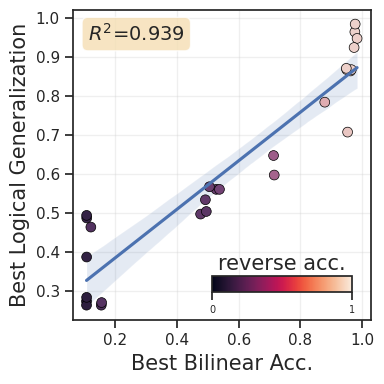

In [176]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.regplot(
    data=merged_best_with_train,
    x='accuracy', y='Logical Generalization (avg)', 
    scatter=False, ax=ax
)

merged_best_with_train["reverse_uni_acc2"] = 1.0 - merged_best_with_train.reverse_uni_acc
# sns.scatterplot(merged_best_with_train, x='accuracy', y='Logical Generalization (avg)', hue='reverse_uni_acc2', legend=False, alpha=1.0, s=50)

sns.scatterplot(
    data=merged_best_with_train,
    x='accuracy', y='Logical Generalization (avg)', 
    hue='reverse_uni_acc2', legend=False, 
    alpha=1.0, s=50, ax=ax, cmap='viridis', edgecolors='black', linewidth=0.5
)

ax.set_xlabel('Best Bilinear Acc.', fontsize=15)
ax.set_ylabel('Best Logical Generalization', fontsize=15)

# correlation coefficient
correlation_best = merged_best['accuracy'].corr(merged_best['Logical Generalization (avg)'])
ax.text(
    0.05, 0.9, f'$R^2$={correlation_best:.3f}', 
    transform=ax.transAxes,
    bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8),
    fontsize=14
)

# colorbar inside plot
# Get the color map from the scatterplot
cmap = ax.collections[0].get_cmap()

# sm.set_norm(norm)
sm = plt.cm.ScalarMappable(cmap=cmap)#, norm=norm)
# sm.set_array([])
# sm.set_cmap(cmap)

# inset colorbar
cax = fig.add_axes([0.55, 0.25, 0.35, 0.04])  # adjust placement
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")

# move title + ticks to top
cbar.set_label('reverse acc.', fontsize=15)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("bottom")
cbar.ax.tick_params(labelsize=7)

# set only 0.0 and 1.0 ticks
cbar.set_ticks([0.0, 1.0])

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("logical_generalization_vs_bilinear.pdf", bbox_inches='tight')

/u/kdkyum/conda-envs/editing/lib/python3.13/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/tmp/ipykernel_147440/3878872841.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


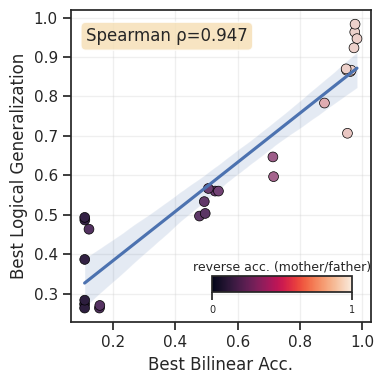

In [177]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.regplot(
    data=merged_best_with_train,
    x='accuracy', y='Logical Generalization (avg)', 
    scatter=False, ax=ax
)

merged_best_with_train["reverse_uni_acc2"] = 1.0 - merged_best_with_train.reverse_uni_acc

sns.scatterplot(
    data=merged_best_with_train,
    x='accuracy', y='Logical Generalization (avg)', 
    hue='reverse_uni_acc2', legend=False, 
    alpha=1.0, s=50, ax=ax, cmap='viridis', edgecolors='black', linewidth=0.5
)

ax.set_xlabel('Best Bilinear Acc.')
ax.set_ylabel('Best Logical Generalization')

# rank (Spearman) correlation
spearman_corr = merged_best['accuracy'].corr(merged_best['Logical Generalization (avg)'], method='spearman')
ax.text(
    0.05, 0.9, f'Spearman ρ={spearman_corr:.3f}', 
    transform=ax.transAxes,
    bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8)
)

# colorbar inside plot
cmap = ax.collections[0].get_cmap()
sm = plt.cm.ScalarMappable(cmap=cmap)

# inset colorbar
cax = fig.add_axes([0.55, 0.25, 0.35, 0.04])  # adjust placement
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")

# move title + ticks to top
cbar.set_label('reverse acc. (mother/father)', fontsize=9)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("bottom")
cbar.ax.tick_params(labelsize=7)

# set only 0.0 and 1.0 ticks
cbar.set_ticks([0.0, 1.0])

ax.grid(True, alpha=0.3)
plt.tight_layout()


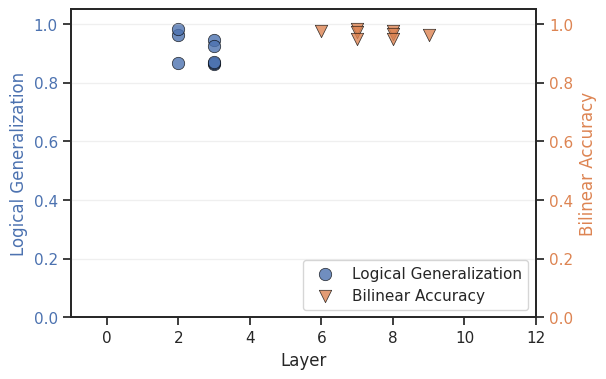

In [178]:

# sns.scatterplot(merged_best[merged_best.accuracy > 0.7], x="Layer", y="Logical Generalization (avg)")
plt.figure(figsize=(6, 4))
ax1 = plt.gca()
ax2 = ax1.twinx()

data_to_plot = merged_best_with_train[merged_best_with_train["reverse_uni_acc"] > 0.98]
data_to_plot = data_to_plot.assign(Layer=data_to_plot["Layer"] + 1)
sns.scatterplot(data=data_to_plot, x="Layer", y="Logical Generalization (avg)", ax=ax1, color='C0', s=80, label='Logical Generalization (avg)', edgecolors='black', linewidth=0.5, alpha=0.8)
sns.scatterplot(data=data_to_plot, x="layer", y="accuracy", ax=ax2, color='C1', marker='v', s=80, label='Bilinear Accuracy', edgecolors='black', linewidth=0.5, alpha=0.8)

ax1.set_xlabel("Layer")
ax1.set_ylabel("Logical Generalization", color="C0")
ax2.set_ylabel("Bilinear Accuracy", color="C1")

ax1.tick_params(axis='y', labelcolor='C0')
ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_xlim(-1, 12)
ax1.set_ylim(0, 1.05)
ax2.set_ylim(0, 1.05)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, ["Logical Generalization"] + labels2, loc='lower right')
ax1.get_legend().remove()

# plt.title("Best LG and Bilinear Accuracy Layer")
plt.grid(True, alpha=0.3)
plt.savefig("SM-best_lg_and_bilinear_layer.pdf", bbox_inches='tight')

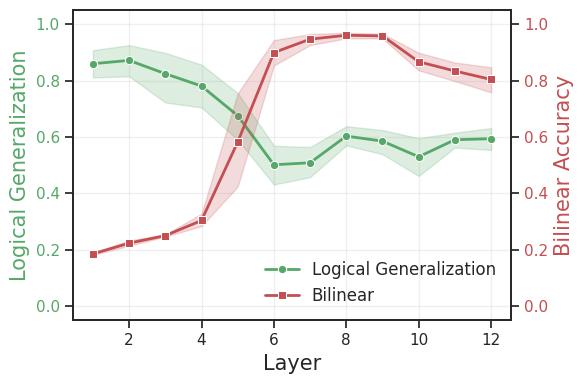

In [179]:
# Line plots over all layers for Not Reversal Cursed (group-wise means)

group_name = "Not Reversal Cursed"

# Build group labels from training results
run_groups = train_df[['Weight Decay', 'Seed', 'reverse_uni_acc']].copy()
run_groups['group'] = 'Neither'
run_groups.loc[run_groups['reverse_uni_acc'] < threshold_low, 'group'] = 'Reversal Cursed'
run_groups.loc[run_groups['reverse_uni_acc'] > threshold_high, 'group'] = group_name

# Prepare bilinear accuracies across layers (relation == overall)
bilinear_all = df_bilinear[df_bilinear['relation'] == 'overall'].rename(columns={'wd': 'Weight Decay', 'seed': 'Seed', 'layer': 'Layer'})
bilinear_all = bilinear_all[bilinear_all["Layer"] > 0]
# aplly layer = layer - 1
# bilinear_all = bilinear_all.assign(Layer=bilinear_all["Layer"] - 1)

# Prepare logical generalization across layers
lg_all = df_plot2[['Weight Decay', 'Seed', 'Layer', 'Logical Generalization (avg)']].copy()

# Keep raw per-run frames; merge with run_groups later to avoid duplicate columns and groupby issues
bilinear_grp = bilinear_all

lg_grp = lg_all
# Plot
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()


# Plot LG with CI directly from per-run data (no manual averaging)
lg_all_sub = (
    lg_all.merge(run_groups, on=['Weight Decay', 'Seed'], how='inner')
          .query('group == @group_name')
)

lg_all_sub = lg_all_sub.assign(Layer=lg_all_sub["Layer"] + 1)

bilinear_all_sub = (
    bilinear_grp.merge(run_groups, on=['Weight Decay', 'Seed'], how='inner')
          .query('group == @group_name')
)
sns.lineplot(
    data=lg_all_sub, x='Layer', y='Logical Generalization (avg)',
    ax=ax1, color='C2', marker='o', linewidth=2, label='Logical Generalization'
)
sns.lineplot(
    data=bilinear_all_sub, x='Layer', y='accuracy',
    ax=ax2, color='C3', marker='s', linewidth=2, label='Bilinear'
)
ax1.set_xlabel("Layer", fontsize=15)
ax1.set_ylabel("Logical Generalization", color="C2", fontsize=15)
ax2.set_ylabel("Bilinear Accuracy", color="C3", fontsize=15)
ax1.tick_params(axis='y', labelcolor='C2')
ax2.tick_params(axis='y', labelcolor='C3')
ax1.set_ylim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
# ax1.set_title(group_name)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
if lines1 or lines2:
    ax1.legend_.remove()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower right', frameon=False, fontsize=12)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("LG_and_Bilinear_not_reversal_cursed.pdf", bbox_inches='tight')

In [180]:
bilinear_grp

,Weight Decay,Seed,l2,Layer,relation,accuracy
17,0.0,0,0.015849,1,overall,0.000000
26,0.0,0,0.015849,2,overall,0.000000
35,0.0,0,0.015849,3,overall,0.000000
44,0.0,0,0.015849,4,overall,0.000000
53,0.0,0,0.015849,5,overall,0.000000
...,...,...,...,...,...,...
3122,6.0,2,0.001995,8,overall,0.856333
3131,6.0,2,0.001995,9,overall,0.761000
3140,6.0,2,0.001995,10,overall,0.722667
3149,6.0,2,0.001995,11,overall,0.680500


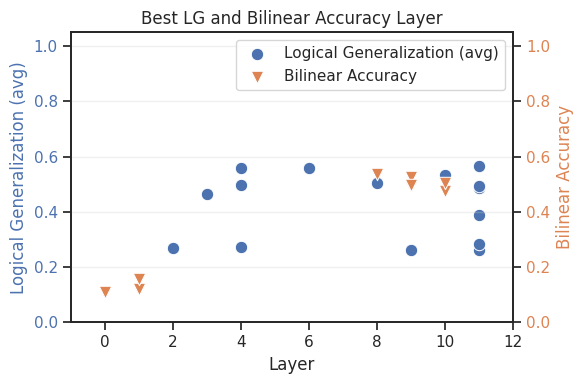

In [181]:
# sns.scatterplot(merged_best[merged_best.accuracy > 0.7], x="Layer", y="Logical Generalization (avg)")
plt.figure(figsize=(6, 4))
ax1 = plt.gca()
ax2 = ax1.twinx()

data_to_plot = merged_best_with_train[merged_best_with_train["reverse_uni_acc"] < 0.5]

sns.scatterplot(data=data_to_plot, x="Layer", y="Logical Generalization (avg)", ax=ax1, color='C0', s=80, label='Logical Generalization (avg)')
sns.scatterplot(data=data_to_plot, x="layer", y="accuracy", ax=ax2, color='C1', marker='v', s=80, label='Bilinear Accuracy')

ax1.set_xlabel("Layer")
ax1.set_ylabel("Logical Generalization (avg)", color="C0")
ax2.set_ylabel("Bilinear Accuracy", color="C1")

ax1.tick_params(axis='y', labelcolor='C0')
ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_xlim(-1, 12)
ax1.set_ylim(0, 1.05)
ax2.set_ylim(0, 1.05)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')
ax1.get_legend().remove()

plt.title("Best LG and Bilinear Accuracy Layer")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
